In [26]:
%pip install langchain-groq
%pip install python-dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict , Annotated
from langchain_core.messages import BaseMessage , HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver
import os
from dotenv import load_dotenv
load_dotenv()


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


True

In [27]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage],add_messages]
    


In [28]:
llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0, groq_api_key=os.getenv("GROQ_API_KEY"))

def chat_node(state : ChatState):
    #take user query from state 
    messages = state["messages"]
    #send to LLM
    response=  llm.invoke(messages)
    #response store state 
    return {'messages':[response]}

In [32]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chat_node" , chat_node)
graph.add_edge(START , 'chat_node')
graph.add_edge('chat_node' , END)

chatbot  = graph.compile(checkpointer=checkpointer)

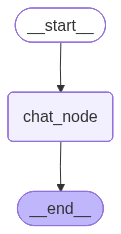

In [33]:
chatbot

In [34]:
initial_state = {
    'messages' :[HumanMessage(content='What is the capital of India ')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [35]:
thread_id ='1'


while True:

    user_message = input('Type here :')
    print('User:' , user_message)

    if user_message.strip().lower() in ['exit' , 'quit','bye']:
        break
    config = {'configurable':{'thread_id':thread_id}}
    response = chatbot.invoke({'messages':[HumanMessage(content=user_message)]},config=config)
    print('AI:' , response['messages'][-1].content)

User: Hi My name is Archit
AI: Hello Archit, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: What is my name ?
AI: Your name is Archit.
User: I am a btech Student at DJSCE 
AI: So, Archit, you're a BTech student at Dwarkadas J. Sanghvi College of Engineering (DJSCE). That's great. What branch of engineering are you pursuing, and what year are you in?
User: Which College Do I study in?
AI: You study at Dwarkadas J. Sanghvi College of Engineering (DJSCE).
User: exit


In [36]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi My name is Archit', additional_kwargs={}, response_metadata={}, id='666e3e96-b30f-4a8e-b954-b59e12dd5f63'), AIMessage(content="Hello Archit, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 41, 'total_tokens': 68, 'completion_time': 0.052073939, 'completion_tokens_details': None, 'prompt_time': 0.00123841, 'prompt_tokens_details': None, 'queue_time': 0.05468037, 'total_time': 0.053312349}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019de292-f179-7a52-820d-0abc31a6d8e2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 27, 'total_tokens': 68}), HumanMessage(content='What is my name ?', additional_kwar